QUMDA

In [17]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import numpy as np
import qiskit
from qiskit import QuantumCircuit
from qiskit import QuantumRegister
from qiskit import ClassicalRegister
from qiskit import transpile
from qiskit.circuit.library import UnitaryGate
from qiskit.providers.basic_provider import BasicProvider
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info.operators import Operator
import heapq
import os

In [18]:
def combine(n):
    # Make diccionary
    combine = {}
    # Generar todas las combinaciones posibles de n bits
    for i in range(2**n):
        # Convertir el número a binario y rellenar con ceros a la izquierda
        combinacion_binaria = format(i, f'0{n}b')
        # Almacenar la combinación en el diccionario
        combine[i] = combinacion_binaria

    return combine

In [19]:
def CreateProbabilityVector(n, SelectedAmount, BS):
    ST = [0.0] * n
    # Accumulate sums for each bit position
    for j in range(n):
        for bs in BS:
            if isinstance(bs, str) and len(bs) > j:
                ST[j] += int(bs[j])  # Convert binary character to integer
        ST[j] /= float(SelectedAmount)
    return ST

In [20]:
def SelectedCadidates(counts, SelectedAmount):
    return heapq.nlargest(SelectedAmount, counts, key=counts.get)
  

In [21]:
def SelectedPopulation(counts, PopulationAmount):
    population = heapq.nlargest(PopulationAmount, counts, key=counts.get)
    populationStr = ' '.join(population)
    return populationStr

In [22]:
#TO DO: Check if achieve the conditions !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
def CheckConditions(counts):
    


    return False

In [23]:
def WriteResults(x, n, bcombine, counts, PopulationAmount):
    populationStr = ""
    f = open("Results.txt", "a")
    f.write(str(x) + " Generations: \n")
    for i in range(2**n):
        f.write("Value for " + bcombine[i] + ":" + str(counts.get(bcombine[i], 0)) + "\n")
    f.write("\n")
    populationStr = SelectedPopulation(counts, PopulationAmount)
    f.write("New population: " + populationStr +  "\n")
    f.write("\n")
    f.close()

In [24]:
def Amplification(qc, n):
    number = 2/(2**n)
    IA2 = np.full((2 ** n, 2 ** n), number)
    for i in range(2 ** n):
        IA2[i, i] -= 1.
    gate1 = UnitaryGate(IA2, label=" -I + 2A")
    qc.unitary(IA2, qc.qubits[:n], label='Amplification')
    

In [25]:
#TO DO: Generated Population with normal distribution, Is not in this case !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
def GeneratedPopulation(qc, n):
    matrix = np.identity(2 ** n, dtype=complex)
    gate = UnitaryGate(matrix, label="Generated Population")
    qc.append(gate, qc.qubits[:n])

In [26]:
def NewPopulation(qc, n, ST, bcombine):
    for j in range(n):
        matrix = np.identity(2 ** n, dtype=complex)
        prob = ST[j]
        if prob != 0.5:
            #Calculate alpha and beta based on the Probability vector or state vector
            alpha = prob + np.sqrt(1 - prob**2) * 1j
            beta = 1 - prob + np.sqrt(1 - (1 - prob)**2) * 1j
        
            for i in range(2**n):
                if bcombine[i][j] == '0':
                    matrix[i][i] = alpha
                else:
                    matrix[i][i] = beta

        gate = UnitaryGate(matrix, label="New Population: Index " + str(j))
        qc.append(gate, qc.qubits[:n])

In [27]:
def BuildCircuit(n, ST, bcombine, generated):
    qc = QuantumCircuit(n, n)
    [qc.h(i) for i in range(n)]
    if (generated):
        NewPopulation(qc, n, ST, bcombine)
        Amplification(qc, n)
    else:
        GeneratedPopulation(qc, n)

    qc.measure(range(n), range(n))
    return qc

In [28]:
#CONSTANT
n = 4
maxGenerations = 4 #QUMDA repetitions
ST = n * [0.]
bcombine = combine(n)
alpha_base = 0.8 + 0.6j # st
beta_base = 0.2 + np.sqrt(1- 0.2**2) * 1j #This is more higher 1 - st
generated = True
SelectedAmount = 4
PopulationAmount = 8
pInit = 0.5

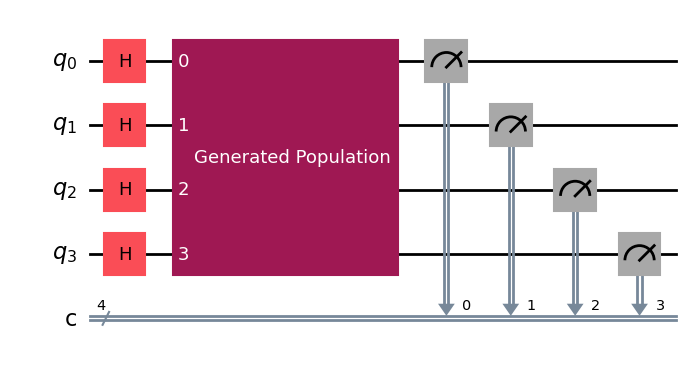

In [29]:
#Generated = False
BuildCircuit(n, ST, bcombine, not generated).draw(output='mpl')

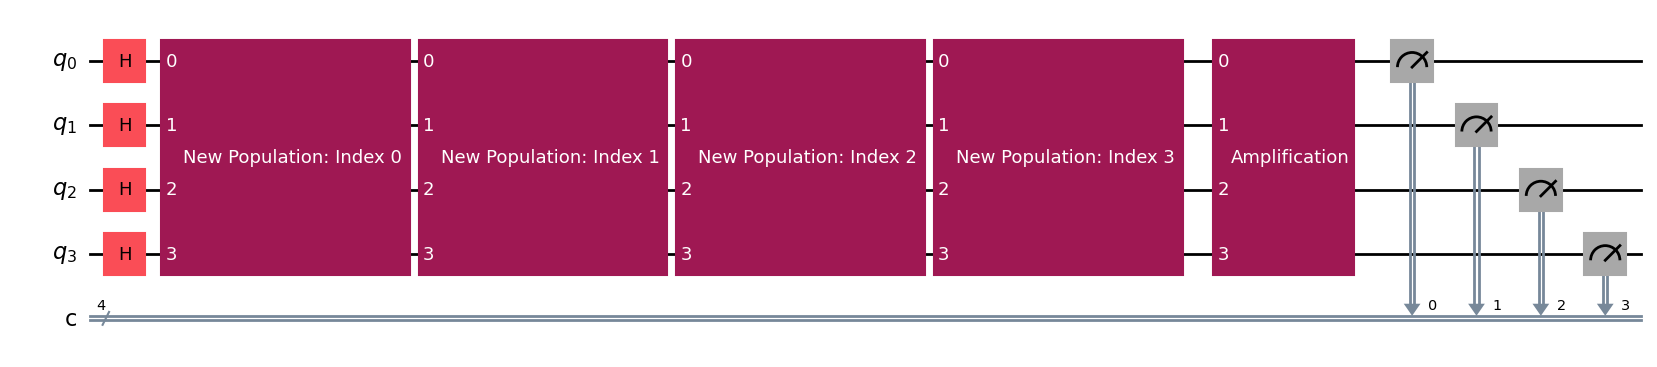

In [30]:
#Generated = True
BuildCircuit(n, ST, bcombine, generated).draw(output='mpl')

In [31]:
t = 0
if os.path.exists("Results.txt"):
    os.remove("Results.txt")
    
backend = BasicProvider().get_backend("basic_simulator")

ST = n * [0.5]
qc = BuildCircuit(n, ST, bcombine, not generated) # QCircuit1

for x in range(maxGenerations): 
    new_circuit = transpile(qc, backend = backend)
    job = backend.run(new_circuit, shots = 1024)
    result = job.result()
    counts = result.get_counts()
    WriteResults(x, n, bcombine, counts, PopulationAmount)
    if (CheckConditions(counts)):
        break
    # BS
    BS = SelectedCadidates(counts, SelectedAmount)
    # Probability vector
    ST = CreateProbabilityVector(n, SelectedAmount, BS)
    #Build new circuit 
    qc = BuildCircuit(n, ST, bcombine, generated) # QCircuit2

